# Day 3.3 — Transparent Persistent Memory
A fact you must not lose belongs in a store you control. Memory is a small set of **selected**
records — who they belong to, where they came from, when they were written — and the user can
read, correct and delete every one.

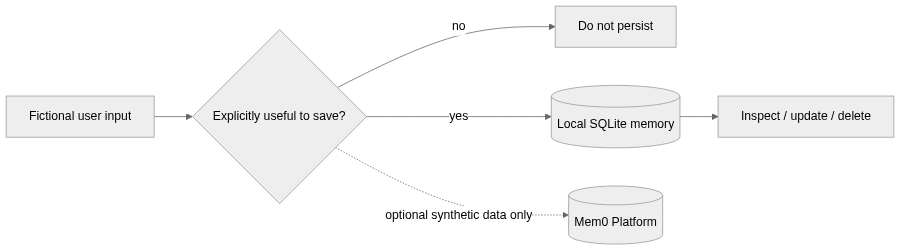

*D10 — decide what is worth saving, store it locally, inspect / update / delete it*

### Step 1 — A store where every operation is scoped by user

Saving every sentence produces a surveillance log, not memory. This store keeps short records with
metadata, and no method can be called without saying *whose* memory it touches.

In [ ]:
import sqlite3, uuid
from datetime import datetime, timezone

def _now():
    return datetime.now(timezone.utc).isoformat()      # microseconds: two writes never tie

class MemoryStore:
    """Small, inspectable memory store. Every query carries a user_id - isolation by construction."""

    def __init__(self, path=":memory:"):
        self.connection = sqlite3.connect(str(path))
        self.connection.row_factory = sqlite3.Row
        self.connection.execute("""CREATE TABLE IF NOT EXISTS memories (
            id TEXT PRIMARY KEY, user_id TEXT NOT NULL, text TEXT NOT NULL,
            source TEXT NOT NULL, created_at TEXT NOT NULL, updated_at TEXT NOT NULL)""")

    def add(self, user_id, text, source="user_confirmed"):
        stamp, memory_id = _now(), uuid.uuid4().hex[:8]
        self.connection.execute("INSERT INTO memories VALUES (?, ?, ?, ?, ?, ?)",
                                (memory_id, user_id, text, source, stamp, stamp))
        self.connection.commit()
        return self.get(user_id, memory_id)

    def get(self, user_id, memory_id):
        row = self.connection.execute("SELECT * FROM memories WHERE user_id=? AND id=?",
                                      (user_id, memory_id)).fetchone()
        return dict(row) if row else None

    def all(self, user_id):
        rows = self.connection.execute(
            "SELECT * FROM memories WHERE user_id=? ORDER BY created_at DESC", (user_id,)).fetchall()
        return [dict(row) for row in rows]

    def search(self, user_id, query, limit=3):
        """Word overlap, plural-tolerant. Deliberately readable - not an embedding model."""
        words = {w.lower().strip(".,!?") for w in query.split() if len(w) > 2}
        ranked = []
        for memory in self.all(user_id):
            stored = {w.lower().strip(".,!?") for w in memory["text"].split()}
            score = sum(any(q == s or q.startswith(s) or s.startswith(q) for s in stored) for q in words)
            if score:
                ranked.append((score, memory))
        return [m for _, m in sorted(ranked, key=lambda item: item[0], reverse=True)[:limit]]

    def update(self, user_id, memory_id, text):
        self.connection.execute("UPDATE memories SET text=?, updated_at=? WHERE user_id=? AND id=?",
                                (text, _now(), user_id, memory_id))
        self.connection.commit()
        return self.get(user_id, memory_id)

    def delete(self, user_id, memory_id):
        cursor = self.connection.execute("DELETE FROM memories WHERE user_id=? AND id=?",
                                         (user_id, memory_id))
        self.connection.commit()
        return cursor.rowcount == 1

print("MemoryStore ready. Columns:", "id, user_id, text, source, created_at, updated_at")

### Step 2 — Seed one fictional user

`SQLite(":memory:")` keeps the database in RAM. Each record says where it came from, so a
preference the user never confirmed can be told apart from one they did.

In [ ]:
users = json.loads((DATA / "synthetic_users.json").read_text(encoding="utf-8"))
asha, omar = users[0]["user_id"], users[1]["user_id"]

store = MemoryStore()
for preference in users[0]["preferences"]:
    store.add(asha, preference, source="synthetic_dataset")

for record in store.all(asha):
    print(f"{record['id']}  {record['text']:<34} source={record['source']}  created={record['created_at'][11:19]}")

### Step 3 — Retrieve a few records, not the whole store

An agent that pastes every memory into the prompt has re-invented the growing history from 3.1.
Retrieval selects the records matching the request in front of it — and returns nothing otherwise.

In [ ]:
for query in ["what time should we meet?", "how should I write the email?", "which lab bench?"]:
    hits = store.search(asha, query)
    print(f"{query:<34} -> {[r['text'] for r in hits] or 'no matching memory'}")

### Step 4 — Isolation, correction, deletion

Omar cannot see Asha's records: no code path in the store ignores the scope. And a memory the user
cannot fix or remove is a liability, not a feature.

In [ ]:
print("Asha's records:", len(store.all(asha)), "| Omar's records:", len(store.all(omar)))
print("Omar searching for Asha's preference:", store.search(omar, "meetings after 10:00"))

oldest = store.all(asha)[-1]
print("\noriginal :", oldest["text"])
corrected = store.update(asha, oldest["id"], "Prefer meetings after 11:00")
print("corrected:", corrected["text"], "| created_at == updated_at?",
      corrected["created_at"] == corrected["updated_at"])
print("deleted  :", store.delete(asha, corrected["id"]))
print("remaining:", [r["text"] for r in store.all(asha)])

### Step 5 — Break it: two memories that contradict each other

Save a preference that conflicts with one already stored, then ask a question both records match.
Similarity ranks text; it cannot decide which sentence is true.

In [ ]:
older = store.add(asha, "Prefer meetings after 10:00", source="explicit_user_statement")
newer = store.add(asha, "Never schedule meetings before 14:00", source="explicit_user_statement")

for record in store.search(asha, "when should we schedule meetings?"):
    print(" -", record["text"], "| written at", record["created_at"][11:19])
print("\nBoth match the words in the question, and they cannot both be obeyed.")

### Step 6 — Resolve it with a written rule

The store cannot decide truth, so the application states a policy. Ours: *the newest explicit
statement wins and the superseded record is removed.* Other defensible rules: ask the user, or keep
both with provenance.

In [ ]:
print("stated first:", older["text"])
print("stated later:", newer["text"])
print("removing the superseded record:", store.delete(asha, older["id"]))
print("memory now answers with one voice:",
      [r["text"] for r in store.search(asha, "when should we schedule meetings?")])
print("\nWe used the order our application recorded, not the wording of the records: similarity")
print("cannot decide truth, and no clock can tell you which statement the user still means.")

### Try it yourself

Predict it first: do records survive if you close a *file-backed* store and open it again in
what a new process would see?

In [ ]:
# --- Worked solution ---------------------------------------------------------------
import tempfile

db_path = Path(tempfile.mkdtemp()) / "memory.db"          # a throwaway folder, not the notebook folder

first_session = MemoryStore(db_path)                      # same class, now backed by a file
first_session.add(asha, "Prefer meetings after 11:00", "explicit_user_statement")
first_session.connection.close()                          # end of "session one"

second_session = MemoryStore(db_path)                     # a brand-new process would do exactly this
print("database file           :", db_path.name)
print("records after reopening :", [r["text"] for r in second_session.all(asha)])

# Persistence is a storage choice, not a model capability: same class, one argument different.

### Checkpoint

**1. Why does every method of the store take a `user_id`?**

<details><summary>Show answer</summary>

So isolation holds by construction. If the scope were optional, one forgotten argument would leak one student's preferences into another student's prompt.

</details>

**2. The store returned two contradictory memories. Whose job is it to fix that?**

<details><summary>Show answer</summary>

The application's. Similarity ranking cannot decide truth, so we applied an explicit rule — newest confirmed statement wins, superseded record deleted — and wrote it down.

</details>

### Recap

- **Limitation seen:** keyword retrieval happily returned two memories that contradicted each other.
- **Layer added:** a user-scoped store with the full lifecycle (add, search, update, delete) and a written conflict rule.
- **Evidence:** Omar's store stayed empty, the corrected record changed text, the deleted record vanished, and the conflicting query ended with one answer.